## Практика 2: Рефакторинг кода

### Работу выполнили студенты ЕТ-128 Бабушкин Михаил, Чашин Денис

Задания типа «По картинке – название». Вам необходимо дать название рефакторинга, который продемонстрирован на изображении.

Есть подклассы, которые различаются только в методах, возвращающих константы. Перенести эти методы в суперкласс, сделав их полями, и удалить подклассы. Если подклассы различаются только в методах, возвращающих константы, то нет смысла загромождать структуру классов, а надо объявить поле в суперклассе и добавить аксессор.
#### Ответ - Замена подкласса полями

Есть метод, который возвращает значение и изменяет состояние объекта. Создать два метода – один для возврата значения, другой для изменения состояния. Хорошим тоном является то, что методы, возвращающие значения, вообще не меняют наблюдаемое состояние объекта. То есть они могут изменять разные кэши, призванные ускорять работу, но не несущие смысловой нагрузки.
#### Ответ - Разделение запроса и модификатора

Есть два метода в подклассах, которые выполняют похожие шаги в одинаковом порядке, хотя сами шаги разные. Поместить шаги в методы с одинаковыми сигнатурами так, чтобы исходные методы стали одинаковыми. Затем исходные методы поместить в суперкласс. Как обычно, убирается дублирование кода с помощью наследования – общая структура выносится в суперкласс, частности описываются в подклассах и включаются в работу благодаря полиморфизму.
#### Ответ - Создание шаблонного метода

Есть проверки на значение Null. Заменить значение Null на объект Null. Преимущество полиморфизма состоит в том, что вместо того, чтобы узнавать, какого типа данный объект, а потом пользоваться его методами в зависимости от ответа, можно напрямую вызывать его методы, не заботясь о его типе. Это касается и пустого объекта (Null объекта), который будет корректно обрабатывать вызовы в отсутствие реального объекта.
#### Ответ - Введение объекта Null

Задания типа «По картинке – код». Вам необходимо написать кусочек кода, демонстрирующий заданный картинкой запах, и кусочек кода, демонстрирующий заданный картинкой рефакторинг.

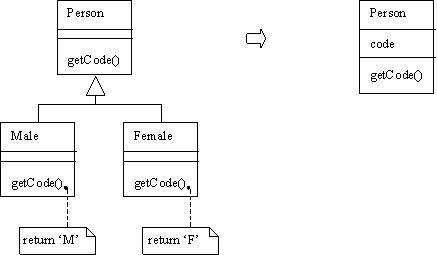

На данном изображении видно, что подклассы класса Person различаются только возвращаемыми значениями. Необходимо выполнить замену подклассов полями

In [ ]:
# Код до рефакторинга

from abc import ABC, abstractmethod

class Person(ABC):
    @abstractmethod
    def get_code(self) -> str:
        pass


class Male(Person):
    def get_code(self) -> str:
        return 'M'


class Female(Person):
    def get_code(self) -> str:
        return 'F'

In [ ]:
# Код после рефакторинга

class Person:
    def __init__(self, code: str):
        self.code = code

    def get_code(self) -> str:
        return self.code

    @staticmethod
    def create_male():
        return Person('M')

    @staticmethod
    def create_female():
        return Person('F')

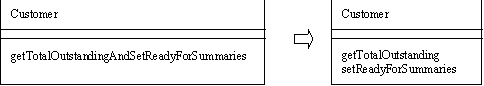

На данном изображени видно, что метод getTotalOutsAndSetReadyForSummaries подразумевает выполнение сразу двух вещей. Необходимо выполнить разделение запроса и модификатора

In [6]:
# Код до рефакторинга

class Customer:
    def __init__(self, orders):
        self.orders = orders
        self.ready_for_summaries = False

    # Метод делает и подсчет и изменяет состояние. Это плохо
    def get_total_outstanding_and_set_ready_for_summaries(self):
        total = sum(self.orders)
        self.ready_for_summaries = True
        return total

In [ ]:
# Код после рефакторинга

class CustomerImproved:
    def __init__(self, orders):
        self.orders = orders
        self.ready_for_summaries = False

    # Метод выполняет только подсчет
    def get_total_outstanding(self) -> float:
        return sum(self.orders)

    # Метод изменяет только состояние
    def set_ready_for_summaries(self) -> None:
        self.ready_for_summaries = True